In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# CHANGED: now loading the pollution-merged dataset
data_path = r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\master_dataset_final.csv"
df = pd.read_csv(data_path)
df['datetime'] = pd.to_datetime(df['datetime'])

print("Dataset loaded!")
print(f"Shape: {df.shape}")

Dataset loaded!
Shape: (32347, 26)


In [2]:
df = df.sort_values('datetime').reset_index(drop=True)
feature_cols = [c for c in df.columns if c not in ['visibility', 'datetime', 'time_gap_hours']]

X = df[feature_cols]
y = df['visibility']

valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

split_index = int(len(X) * 0.8)
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"Training rows: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Testing rows:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

X shape: (32347, 24)
y shape: (32347,)
Training rows: 25877 (80.0%)
Testing rows:  6470 (20.0%)


In [3]:

print("Training Random Forest... please wait!")

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
print("Random Forest training complete!")

# Evaluate
rf_pred = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_pred)
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print(f"\nRandom Forest Results:")
print(f"R²   : {rf_r2:.4f}")
print(f"MAE  : {rf_mae:.4f} km")
print(f"RMSE : {rf_rmse:.4f} km")

Training Random Forest... please wait!
Random Forest training complete!

Random Forest Results:
R²   : 0.8974
MAE  : 1.4769 km
RMSE : 2.9554 km


In [4]:
# Train XGBoost
print("Training XGBoost... please wait!")

xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
print("XGBoost training complete!")

# Evaluate
xgb_pred = xgb_model.predict(X_test)

xgb_r2   = r2_score(y_test, xgb_pred)
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"\nXGBoost Results:")
print(f"R²   : {xgb_r2:.4f}")
print(f"MAE  : {xgb_mae:.4f} km")
print(f"RMSE : {xgb_rmse:.4f} km")

Training XGBoost... please wait!
XGBoost training complete!

XGBoost Results:
R²   : 0.9121
MAE  : 1.6910 km
RMSE : 2.7363 km


In [5]:
import numpy as np

# Give extra importance to rows where visibility is CRITICAL-range
# so the model can't afford to ignore them anymore
sample_weights = np.where(y_train < 0.5, 5, 1)  # CRITICAL rows count 5x more

xgb_model_weighted = xgb.XGBRegressor(
    n_estimators=100, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)

xgb_model_weighted.fit(X_train, y_train, sample_weight=sample_weights)
print("Weighted XGBoost training complete!")

Weighted XGBoost training complete!


In [6]:
# Evaluate weighted model on test set
weighted_pred = xgb_model_weighted.predict(X_test)

# Quick risk classification check — did CRITICAL recall improve?
def classify_risk(v):
    if v < 0.5: return "CRITICAL"
    elif v < 2.0: return "HIGH"
    elif v < 5.0: return "MODERATE"
    elif v < 10.0: return "LOW"
    else: return "SAFE"

actual_risk = y_test.apply(classify_risk)
predicted_risk_weighted = pd.Series(weighted_pred, index=y_test.index).apply(classify_risk)

from sklearn.metrics import classification_report
print("=== Weighted Model — Risk Classification ===")
print(classification_report(actual_risk, predicted_risk_weighted,
                             labels=['CRITICAL','HIGH','MODERATE','LOW','SAFE']))

=== Weighted Model — Risk Classification ===
              precision    recall  f1-score   support

    CRITICAL       0.62      0.55      0.58       205
        HIGH       0.66      0.47      0.55       756
    MODERATE       0.83      0.69      0.75      2750
         LOW       0.32      0.61      0.42       689
        SAFE       0.88      0.92      0.90      2070

    accuracy                           0.72      6470
   macro avg       0.66      0.65      0.64      6470
weighted avg       0.76      0.72      0.73      6470



In [7]:
# Reload no-pollution data to test weighting on it too
df_np = pd.read_csv(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\master_dataset_features.csv")
df_np['datetime'] = pd.to_datetime(df_np['datetime'])
df_np = df_np.sort_values('datetime').reset_index(drop=True)

feature_cols_np = [c for c in df_np.columns if c not in ['visibility', 'datetime', 'time_gap_hours']]
X_np = df_np[feature_cols_np].dropna()
y_np = df_np.loc[X_np.index, 'visibility']

split_np = int(len(X_np) * 0.8)
X_train_np, X_test_np = X_np.iloc[:split_np], X_np.iloc[split_np:]
y_train_np, y_test_np = y_np.iloc[:split_np], y_np.iloc[split_np:]

weights_np = np.where(y_train_np < 0.5, 5, 1)
xgb_np_weighted = xgb.XGBRegressor(n_estimators=100, max_depth=6, learning_rate=0.1,
                                     subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_np_weighted.fit(X_train_np, y_train_np, sample_weight=weights_np)

pred_np = xgb_np_weighted.predict(X_test_np)
actual_risk_np = y_test_np.apply(classify_risk)
predicted_risk_np = pd.Series(pred_np, index=y_test_np.index).apply(classify_risk)

print("=== No-Pollution + Weighted — Risk Classification ===")
print(classification_report(actual_risk_np, predicted_risk_np, labels=['CRITICAL','HIGH','MODERATE','LOW','SAFE']))

=== No-Pollution + Weighted — Risk Classification ===
              precision    recall  f1-score   support

    CRITICAL       0.61      0.60      0.60       205
        HIGH       0.65      0.52      0.58       826
    MODERATE       0.85      0.77      0.81      3241
         LOW       0.38      0.59      0.46       739
        SAFE       0.90      0.93      0.91      2435

    accuracy                           0.77      7446
   macro avg       0.68      0.68      0.67      7446
weighted avg       0.79      0.77      0.78      7446



In [8]:
import joblib
joblib.dump(xgb_np_weighted, r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\xgb_model_final.pkl")

# Also save this test set with predictions, for Week 7
test_export_final = df_np.loc[X_test_np.index].copy()
test_export_final['predicted_visibility'] = pred_np
test_export_final.to_csv(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\test_set_with_predictions.csv", index=False)
print("Final model and test set saved!")

Final model and test set saved!


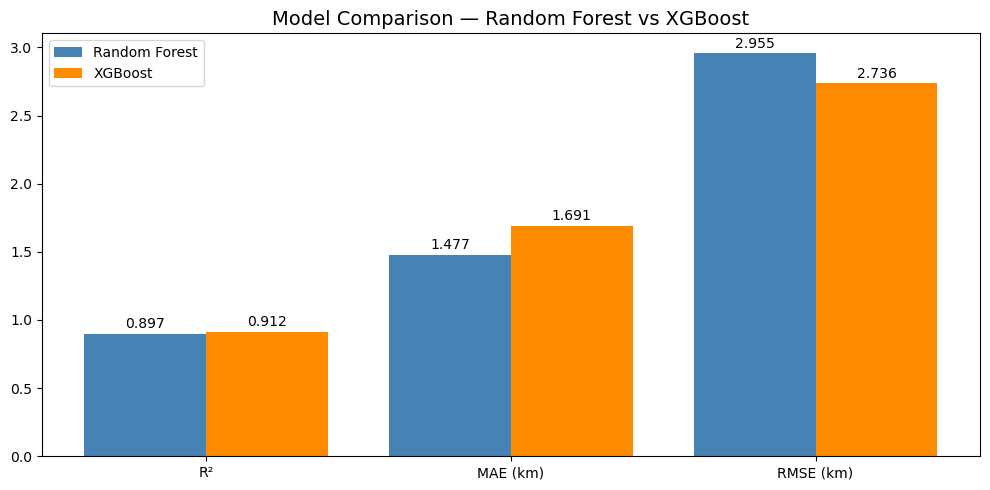

Done!


In [9]:
import matplotlib.pyplot as plt

# Comparison bar chart
metrics = ['R²', 'MAE (km)', 'RMSE (km)']
rf_scores  = [rf_r2, rf_mae, rf_rmse]
xgb_scores = [xgb_r2, xgb_mae, xgb_rmse]

x = range(len(metrics))
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar([i - 0.2 for i in x], rf_scores, 
               width=0.4, label='Random Forest', color='steelblue')
bars2 = ax.bar([i + 0.2 for i in x], xgb_scores, 
               width=0.4, label='XGBoost', color='darkorange')

ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_title('Model Comparison — Random Forest vs XGBoost', fontsize=14)
ax.legend()

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 0.02,
            f'{bar.get_height():.3f}', 
            ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\model_comparison.png", dpi=150)
plt.show()
print("Done!")

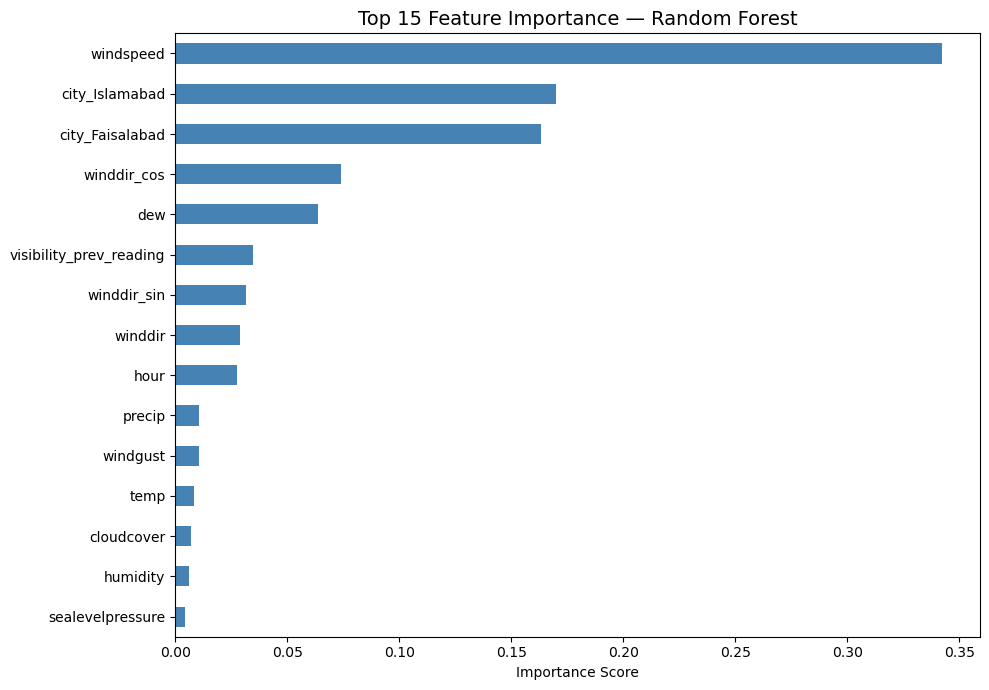

Done!


In [10]:
# Feature Importance — Random Forest
feat_imp_rf = pd.Series(
    rf_model.feature_importances_, 
    index=X.columns
).sort_values(ascending=True).tail(15)

plt.figure(figsize=(10, 7))
feat_imp_rf.plot(kind='barh', color='steelblue')
plt.title('Top 15 Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig(r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\feature_importance_rf.png", dpi=150)
plt.show()
print("Done!")

In [11]:
import joblib

# Save both models
joblib.dump(rf_model, 
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\rf_model.pkl")
joblib.dump(xgb_model, 
    r"C:\Users\Admin\OneDrive\Desktop\FYP_Dataset\xgb_model.pkl")

print("Both models saved!")
print("rf_model.pkl ✅")
print("xgb_model.pkl ✅")


Both models saved!
rf_model.pkl ✅
xgb_model.pkl ✅
